In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import pandas_ta as ta

In [2]:
# Load and prepare data
df = pd.read_csv('/home/qa/runtime/data/analysis_out/garch/reliance_1d_10y.csv',
    parse_dates=['Date'], index_col='Date').sort_index()

df.index = pd.to_datetime(df.index)
del df["Dividends"]
del df["Stock Splits"]


In [5]:
df['Returns'] = np.log(df['Close'] / df['Close'].shift(1))

# windows = [7, 14, 21, 60, 100]
windows = [7]
for w in windows:
    df['RSI_{}'.format(w)] = ta.rsi(df['Close'], length=w)
    df['SMA_{}'.format(w)] = ta.sma(df['Close'], length=w)
    df['EMA_{}'.format(w)] = ta.ema(df['Close'], length=w)
    df['Volatility_{}'.format(w)] = ta.stdev(df['Returns'], length=w)
    
    adx = ta.adx(df['High'], df['Low'], df['Close'], length=w)
    df = pd.concat([df, adx], axis=1)
    
    bbands = ta.bbands(df['Close'], length=w, std=2)
    df = pd.concat([df, bbands], axis=1)

macd_df = ta.macd(df['Close'], fast=12, slow=26, signal=9)
df = pd.concat([df, macd_df], axis=1)

df['ADV_21'] = ta.sma(df['Volume'], length=21)
df['Pct_Adv'] = df['Volume'] / df['ADV_21']

# If next day open is more than previous close set 1 else 0
df['Open_Direction'] = (df['Open'].shift(-1) > df['Close']).astype(int)

df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df.dropna(inplace=True)  # Drop NaN values
print(df)

# get all the columns from the dataframe as a list
columns = df.columns.tolist()
print(columns)

# remove target from the columns list
columns = [c for c in columns if c not in ['Target']]

                                  Open         High          Low        Close  \
Date                                                                            
2015-04-09 00:00:00+05:30   182.810695   189.886552   181.395520   189.062790   
2015-04-10 00:00:00+05:30   189.031106   191.956500   187.795477   191.016571   
2015-04-13 00:00:00+05:30   191.534035   195.325434   189.833723   194.850189   
2015-04-15 00:00:00+05:30   194.533349   198.462037   191.618530   195.093094   
2015-04-16 00:00:00+05:30   195.272630   198.124099   194.110926   196.085831   
...                                ...          ...          ...          ...   
2025-02-11 00:00:00+05:30  1264.550049  1264.550049  1230.099976  1234.849976   
2025-02-12 00:00:00+05:30  1219.449951  1226.900024  1193.349976  1216.550049   
2025-02-13 00:00:00+05:30  1217.050049  1228.000000  1212.000000  1216.099976   
2025-02-14 00:00:00+05:30  1219.000000  1224.000000  1205.449951  1217.250000   
2025-02-17 00:00:00+05:30  1

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=150, min_samples_split=100, random_state=10)

train = df.iloc[:-100]
test = df.iloc[-100:]

# predictors = columns
# "Volume", "Open", "High", "Low", "Volatility_14", "ADX_100", "Pct_Adv",
predictors = ["Close", "Volume", "Open", "High", "Low", "Volatility_14", "ADX_100", "Pct_Adv", "Open_Direction"]
model.fit(train[predictors], train["Target"])

In [ ]:
# from sklearn.metrics import precision_score

# preds = model.predict(test[predictors])
# preds = pd.Series(preds, index=test.index)
# precision_score(test["Target"], preds)

def directional_precision(y_true, y_pred):
    correct_predictions = (y_true == y_pred).sum()  # Count where actual == predicted
    total_predictions = len(y_true)  # Total test samples
    precision = correct_predictions / total_predictions  # Compute precision
    return precision

preds = model.predict(test[predictors])
preds = pd.Series(preds, index=test.index)
precision = directional_precision(test["Target"], preds)
print(f"Precision: {precision:.4f}")

In [ ]:
features = ["Close", "Volume", "Open", "High", "Low", "Volatility_14", "ADX_100", "Pct_Adv", "Open_Direction"]
X = df[features]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

In [ ]:
y_pred = clf.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification Report
print(classification_report(y_test, y_pred))

In [ ]:
importances = pd.Series(clf.feature_importances_, index=features)
importances.sort_values().plot(kind="barh", title="Feature Importance")
plt.show()

In [ ]:
latest_data = X.iloc[-1:].values  # Get the most recent available data
print(latest_data)
prediction = clf.predict(latest_data)

if prediction[0] == 1:
    print("Stock is predicted to go UP tomorrow.")
else:
    print("Stock is predicted to go DOWN tomorrow.")

In [ ]:
combined = pd.concat([test["Target"], preds], axis=1)
combined.plot()
combined

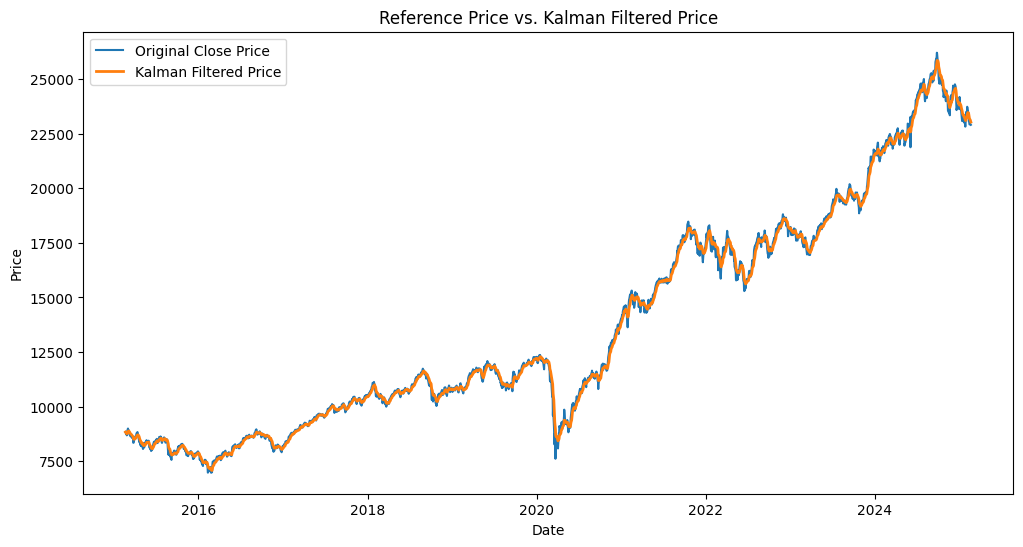

                              Original     Filtered
Date                                               
2015-02-19 18:30:00+00:00  8833.599609  8833.599609
2015-02-22 18:30:00+00:00  8754.950195  8793.315764
2015-02-23 18:30:00+00:00  8762.099609  8782.081847
2015-02-24 18:30:00+00:00  8767.250000  8777.769973
2015-02-25 18:30:00+00:00  8683.849609  8753.901933
2015-02-26 18:30:00+00:00  8844.599609  8775.053143
2015-03-01 18:30:00+00:00  8956.750000  8815.153944
2015-03-02 18:30:00+00:00  8996.250000  8853.733421
2015-03-03 18:30:00+00:00  8922.650391  8868.085738
2015-03-04 18:30:00+00:00  8937.750000  8882.384234
                           SMA_Signal_1  EMA_Signal_1  RSI_Signal  \
Date                                                                
2025-02-13 18:30:00+00:00             0             0           0   
2025-02-16 18:30:00+00:00             0             0           0   
2025-02-17 18:30:00+00:00             0             0           0   
2025-02-18 18:30:00+00:00      

/home/qa/BlingTradePlatform/strategy/MomentumLearning/StrategyRepos/../../MomentumLearning/StrategyRepos/common_indicators.py:304: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Distance'] = df['Midpoint'].diff().fillna(method='bfill').fillna(0)


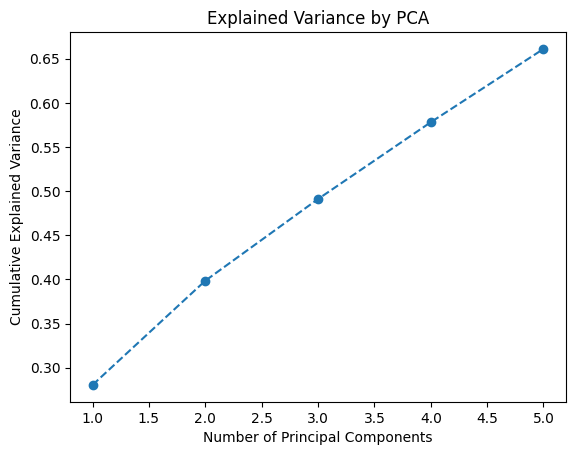

start = 0, window_size = 2164, step_size = 3, test_size = 200
Training data size = 2164, Test data size = 3
Rolling Window 1 | Precision: 0.0000
start = 3, window_size = 2164, step_size = 3, test_size = 200
Training data size = 2167, Test data size = 3
Rolling Window 2 | Precision: 0.5000
start = 6, window_size = 2164, step_size = 3, test_size = 200
Training data size = 2170, Test data size = 3
Rolling Window 3 | Precision: 1.0000
start = 9, window_size = 2164, step_size = 3, test_size = 200
Training data size = 2173, Test data size = 3
Rolling Window 4 | Precision: 1.0000
start = 12, window_size = 2164, step_size = 3, test_size = 200
Training data size = 2176, Test data size = 3
Rolling Window 5 | Precision: 0.0000
start = 15, window_size = 2164, step_size = 3, test_size = 200
Training data size = 2179, Test data size = 3
Rolling Window 6 | Precision: 1.0000
start = 18, window_size = 2164, step_size = 3, test_size = 200
Training data size = 2182, Test data size = 3
Rolling Window 7 | 

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.ensemble import RandomForestClassifier
from pykalman import KalmanFilter
# from tensorflow.keras.layers import LSTM, Dense
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import make_scorer

import os
import sys

sys.path.append(os.path.dirname(os.path.realpath('__file__')) + '/../../')
from MomentumLearning.StrategyRepos.common_indicators import *


def custom_precision_score(y_true, y_pred, positive_label=1):
    """
    Custom precision scorer to measure how many predicted 'Up' (1) cases 
    were actually correct.

    Formula: 
        Precision = True Positives (TP) / Total Predicted Ups (TP + FP)

    Parameters:
    - y_true: Array of actual values (ground truth).
    - y_pred: Array of predicted values.
    - positive_label: The label to calculate precision for (default = 1 for 'Up' movements).

    Returns:
    - Precision score as a float.
    """
    # Convert inputs to NumPy arrays (if they aren't already)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Count True Positives (TP): Cases where y_pred = 1 and y_true = 1
    TP = np.sum((y_pred == positive_label) & (y_true == positive_label))

    # Count Total Predicted Ups (TP + FP): All cases where y_pred = 1
    total_predicted_positive = np.sum(y_pred == positive_label)

    # Avoid division by zero
    if total_predicted_positive == 0:
        return 0.0  # If no 'Up' predictions were made, precision is 0

    # Calculate precision
    precision = TP / total_predicted_positive
    return precision

# Create a Scikit-learn compatible scorer
custom_precision_scorer = make_scorer(custom_precision_score, greater_is_better=True)


def directional_precision(y_true, y_pred):
    # Iterate over y_pred , if y_pred is 1 and y_true is 1 then it is correct prediction
    # if y_pred is 1 then count in denominator

    precision = precision_score(test["Target"], preds, pos_label=1)
    # correct_predictions = (y_true == y_pred).sum()  # Count where actual == predicted
    # total_predictions = len(y_true)  # Total test samples
    # precision = correct_predictions / total_predictions  # Compute precision
    return precision

def directional_classification_report(y_true, y_pred):
    """
    Computes precision, recall, and F1-score considering both class 0 and class 1.
    """
    dp = directional_precision(y_true, y_pred)
    
    recall = dp
    f1 = 0 if (dp == 0) else 2 * (dp * recall) / (dp + recall)
    
    print(f"Directional Precision: {dp:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

def enrich_features_and_target(df):
    df['Returns'] = np.log(df['Close'] / df['Close'].shift(1))

    windows = [7, 14, 21, 60, 100]
    for w in windows:
        df['RSI_{}'.format(w)] = ta.rsi(df['Close'], length=w)
        df['SMA_{}'.format(w)] = ta.sma(df['Close'], length=w)
        df['EMA_{}'.format(w)] = ta.ema(df['Close'], length=w)
        df['Volatility_{}'.format(w)] = ta.stdev(df['Returns'], length=w)
        
        adx = ta.adx(df['High'], df['Low'], df['Close'], length=w)
        df = pd.concat([df, adx], axis=1)
        
        bbands = ta.bbands(df['Close'], length=w, std=2)
        df = pd.concat([df, bbands], axis=1)

    macd_df = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    df = pd.concat([df, macd_df], axis=1)

    df['ADV_21'] = ta.sma(df['Volume'], length=21)
    df['Pct_Adv'] = df['Volume'] / df['ADV_21']

    # If next day open is more than previous close set 1 else 0
    df['Open_Direction'] = (df['Open'].shift(-1) > df['Close']).astype(int)

    df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
    df.dropna(inplace=True)  # Drop NaN values
    return df

def enrich_trend_signals(df):
    df = sma_ema_signals(df)
    df = rsi_signals(df)
    df = macd_signals(df)
    df = stochastic_signals(df)
    df = smi_signals(df)
    df = rvi_signals(df)
    df = emv_signals(df)
    df = reynolds_signals(df)
    df = next_day_open_direction(df)
    df = count_last_n_days(df)
    df['Day_of_Week'] = df.index.dayofweek 
    
    # tech_indicators = [
    #     'SMA_Signal_1', 'SMA_Signal_2', 'EMA_Signal_1', 'EMA_Signal_2','RSI_Signal', 
    #     'MACD_Signal', 'Stochastic_Signal', 'SMI_Signal', 'RVI_Signal', 'EMV_Signal', 'RN_Signal'
    # ]
    tech_indicators = [
        'SMA_Signal_1', 'EMA_Signal_1', 'RSI_Signal', 'MACD_Signal', 'Stochastic_Signal',
        'SMI_Signal', 'RVI_Signal', 'EMV_Signal', 'RN_Signal', 'Open_Direction' , 'Day_of_Week', 'Up_Days', 'Down_Days'
    ]
    # tech_indicators = [
    #     'Open', 'High', 'Low', 'Ref_Price', 'Volume', 
    #     'SMA_10', 'SMA_20', 'SMA_100', 'EMA_10', 'EMA_20', 'EMA_50', 'RSI', 'MACD', 'MACD_Signal_Line',
    #     '%K', '%D', '%K_Previous', '%D_Previous', 'SMI', 'SMI_Previous', 'RVI', 'RVI_Prev', 'RVI_Prev_Prev',
    #     'EMV', 'EMV_Prev', 'RN', 'RN_Upper', 'RN_Lower'
    # ]
    signals_df = df[tech_indicators].copy()

    print(signals_df.tail())
    return df, tech_indicators

def get_pca_components(df, predictors, n_components=5):
    X = df[predictors]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA(n_components=n_components)
    components = pca.fit_transform(X_scaled)
    
    # Get eigenvectors (principal components)
    eigenvectors = pca.components_

    # Get eigenvalues (variance explained by each component)
    eigenvalues = pca.explained_variance_

    # Create DataFrame for visualization
    eigenvector_df = pd.DataFrame(eigenvectors.T, columns=[f'PCA_{i+1}' for i in range(n_components)], index=predictors)

    # Create Explained Variance DataFrame  ,
    explained_variance_df = pd.DataFrame(
        {'Principal Component': [f'PCA_{i+1}' for i in range(n_components)], 'Explained Variance': eigenvalues}
    )
    
    print(eigenvector_df)
    print(explained_variance_df)
    
    pca_df = pd.DataFrame(components, columns=[f'PCA_{i+1}' for i in range(n_components)], index=df.index)
    pca_df['Target'] = df['Target']
    print(pca_df.head(20))
    
    # Explained variance
    explained_variance = pca.explained_variance_ratio_

    # Plot explained variance
    plt.plot(range(1, len(explained_variance) + 1), explained_variance.cumsum(), marker='o', linestyle='--')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('Explained Variance by PCA')
    plt.show()
    
    return pca_df, [f'PCA_{i+1}' for i in range(n_components)]

# ✅ Step 1: Download Data
df = pd.read_csv('/home/qa/runtime/data/analysis_out/garch/nifty_1d_10y.csv',
    parse_dates=['Date'], index_col='Date').sort_index()

df.index = pd.to_datetime(df.index, utc=True)
del df["Dividends"]
del df["Stock Splits"]

# ✅ Step 2: Select a Reference price and smoothen it using kalman filter
# df['Ref_Price'] = ( df['High'] + df['Low'] + df['Close'] ) / 3
df['Ref_Price'] = df['Close']
df = get_kalman_filter_price(df)

# ✅ Step 2: Create Features & Target
df, predictors = enrich_trend_signals(df)
df['Target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)
df.dropna(inplace=True)  # Drop NaN values

# ✅ Step 3: Dimensionality Reduction via PCA
df, predictors = get_pca_components(df, predictors, n_components=5)

# ✅ Step 4: Define Features for Prediction
# predictors = ["Close", "Volume", "Open", "High", "Low", "Volatility_14", "ADX_100", "Pct_Adv"]
sample_size = len(df)
window_size = sample_size -200 #int(0.8 * sample_size)  # 80% train-test split
step_size = 3  # Move window forward by 20
test_size = sample_size - window_size  # Total test samples

# Store performance metrics
precision_scores = []

# ✅ Step 5: Rolling Window Prediction
for start in range(0, test_size, step_size):
    # Define train-test split dynamically
    print(f'start = {start}, window_size = {window_size}, step_size = {step_size}, test_size = {test_size}')    
    
    train = df.iloc[: start + window_size]
    # print(train.shape)
    # print(train.head(10))
    test = df.iloc[start + window_size : start + window_size + step_size]
    # print(test.shape)
    # print(test.head(10))
    
    print(f'Training data size = {len(train)}, Test data size = {len(test)}')

    # Check if test set is empty (happens at the end)
    if test.empty:
        break

    # Train RandomForest Model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    # model = RandomForestClassifier(
    #     class_weight={0: 1, 1: 3},  # 3x penalty for false "Up" predictions
    #     n_estimators=200,
    #     max_depth=8,  # Reduce overfitting
    #     min_samples_leaf=5,
    #     random_state=42
    # )
    # Train SVC Model
    # model = SVC(kernel='rbf')
    
    ########## Model Fit logic ###########
    model.fit(train[predictors], train["Target"])
    
    # Predict on the next 5 data points
    preds = model.predict(test[predictors])

    # Evaluate performance
    # precision = directional_precision(test["Target"], preds)
    precision = custom_precision_score(test["Target"], preds, positive_label=1)
    
    #####################
    
    ################# Use cross-validation with the custom precision scorer
    # scores = cross_val_score(model, train[predictors], train["Target"], cv=10, scoring=custom_precision_scorer)

    # # Store the mean precision score
    # precision = scores.mean()
    
    ################################

    precision_scores.append(precision)

    print(f"Rolling Window {start // step_size + 1} | Precision: {precision:.4f}")

# ✅ Step 5: Evaluate Overall Performance
print("\nFinal Precision Score:", np.mean(precision_scores))
print("\n Max precision score: ", max(precision_scores))
print("\n Min precision score: ", min(precision_scores))
print("\n percentile precision score: ", np.percentile(precision_scores, 50))
# print("\nClassification Report:\n", directional_classification_report(test["Target"], preds))
# print("\nFeature Importance:\n", model.feature_importances_)


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from pykalman import KalmanFilter

# Download SPY OHLC data (adjust start/end dates as needed).
data = pd.read_csv('/home/qa/runtime/data/analysis_out/garch/spy_1d_10y.csv',
    parse_dates=['Date'], index_col='Date').sort_index()

data.index = pd.to_datetime(data.index, utc=True)
del data["Dividends"]
del data["Stock Splits"]
close_prices = data['Close']

# Configure the Kalman Filter with a simple random walk model.
kf = KalmanFilter(
    transition_matrices=[1],
    observation_matrices=[1],
    initial_state_mean=close_prices.iloc[0],
    initial_state_covariance=1,
    observation_covariance=1,
    transition_covariance=0.01
)

# Use kf.filter() for causal filtering.
state_means, _ = kf.filter(close_prices.values)
filtered_prices = pd.Series(state_means.flatten(), index=close_prices.index)

# Plot the original close prices and the Kalman filter estimates.
plt.figure(figsize=(12, 6))
plt.plot(close_prices, label="Original Close Price")
plt.plot(filtered_prices, label="Kalman Filtered Price", linewidth=2)
plt.title("SPY Close Price vs. Kalman Filtered Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# Display a few sample values.
result = pd.DataFrame({
    "Original": close_prices,
    "Filtered": filtered_prices
})
print(result.head(10))
